In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the csv files

In [2]:
patients = pd.read_csv("patients.csv")
diagnoses = pd.read_csv("diagnoses.csv")
labs = pd.read_csv("labs.csv")
outcomes = pd.read_csv("outcomes.csv")

# check the columns

In [3]:
print(patients.columns)
print(diagnoses.columns)
print(labs.columns)
print(outcomes.columns)

Index(['PatientID', 'Name', 'Age', 'Gender', 'DiagnosisID', 'AdmissionDate',
       'DischargeDate', 'OutcomeID', 'TreatmentCost'],
      dtype='object')
Index(['DiagnosisID', 'DiagnosisName'], dtype='object')
Index(['LabID', 'PatientID', 'TestName', 'Result', 'NormalRange'], dtype='object')
Index(['OutcomeID', 'OutcomeName'], dtype='object')


# merge the csv files into one dataframe

In [4]:
df = (patients
      .merge(diagnoses, on="DiagnosisID", how="left")
      .merge(labs, on="PatientID", how="left")
      .merge(outcomes, on="OutcomeID", how="left"))

# check for null values

In [7]:
df.isnull().sum()

PatientID         0
Name              0
Age               0
Gender            0
DiagnosisID       0
AdmissionDate     0
DischargeDate     0
OutcomeID         0
TreatmentCost     0
DiagnosisName     0
LabID            69
TestName         69
Result           69
NormalRange      69
OutcomeName       0
dtype: int64

# drop rows containing nulls

In [8]:
df = df.dropna()

# check the final df

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 268
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      200 non-null    int64  
 1   Name           200 non-null    object 
 2   Age            200 non-null    int64  
 3   Gender         200 non-null    object 
 4   DiagnosisID    200 non-null    int64  
 5   AdmissionDate  200 non-null    object 
 6   DischargeDate  200 non-null    object 
 7   OutcomeID      200 non-null    int64  
 8   TreatmentCost  200 non-null    int64  
 9   DiagnosisName  200 non-null    object 
 10  LabID          200 non-null    float64
 11  TestName       200 non-null    object 
 12  Result         200 non-null    float64
 13  NormalRange    200 non-null    object 
 14  OutcomeName    200 non-null    object 
dtypes: float64(2), int64(5), object(8)
memory usage: 25.0+ KB


In [10]:
df.head()

,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost,DiagnosisName,LabID,TestName,Result,NormalRange,OutcomeName
1,2,Jessica Zimmerman,81,M,2,2025-03-31,2025-04-02,2,4265,Diabetes,21.0,Blood Sugar,245.0,13-17,Complicated
3,4,Lori Green,44,F,3,2025-04-03,2025-04-05,1,9783,Heart Disease,56.0,Vitamin D,162.8,0.6-1.2,Recovered
4,5,Jack Logan,72,F,9,2025-06-03,2025-06-04,1,5005,Kidney Disease,32.0,Cholesterol,67.0,13-17,Recovered
6,7,Sherry Robinson,50,F,1,2025-06-11,2025-07-05,2,2984,Hypertension,7.0,Blood Pressure,133.8,150-200,Complicated
7,7,Sherry Robinson,50,F,1,2025-06-11,2025-07-05,2,2984,Hypertension,9.0,Hemoglobin,90.2,20-50,Complicated


# Make univariant and bivariant plots to visualize the Data

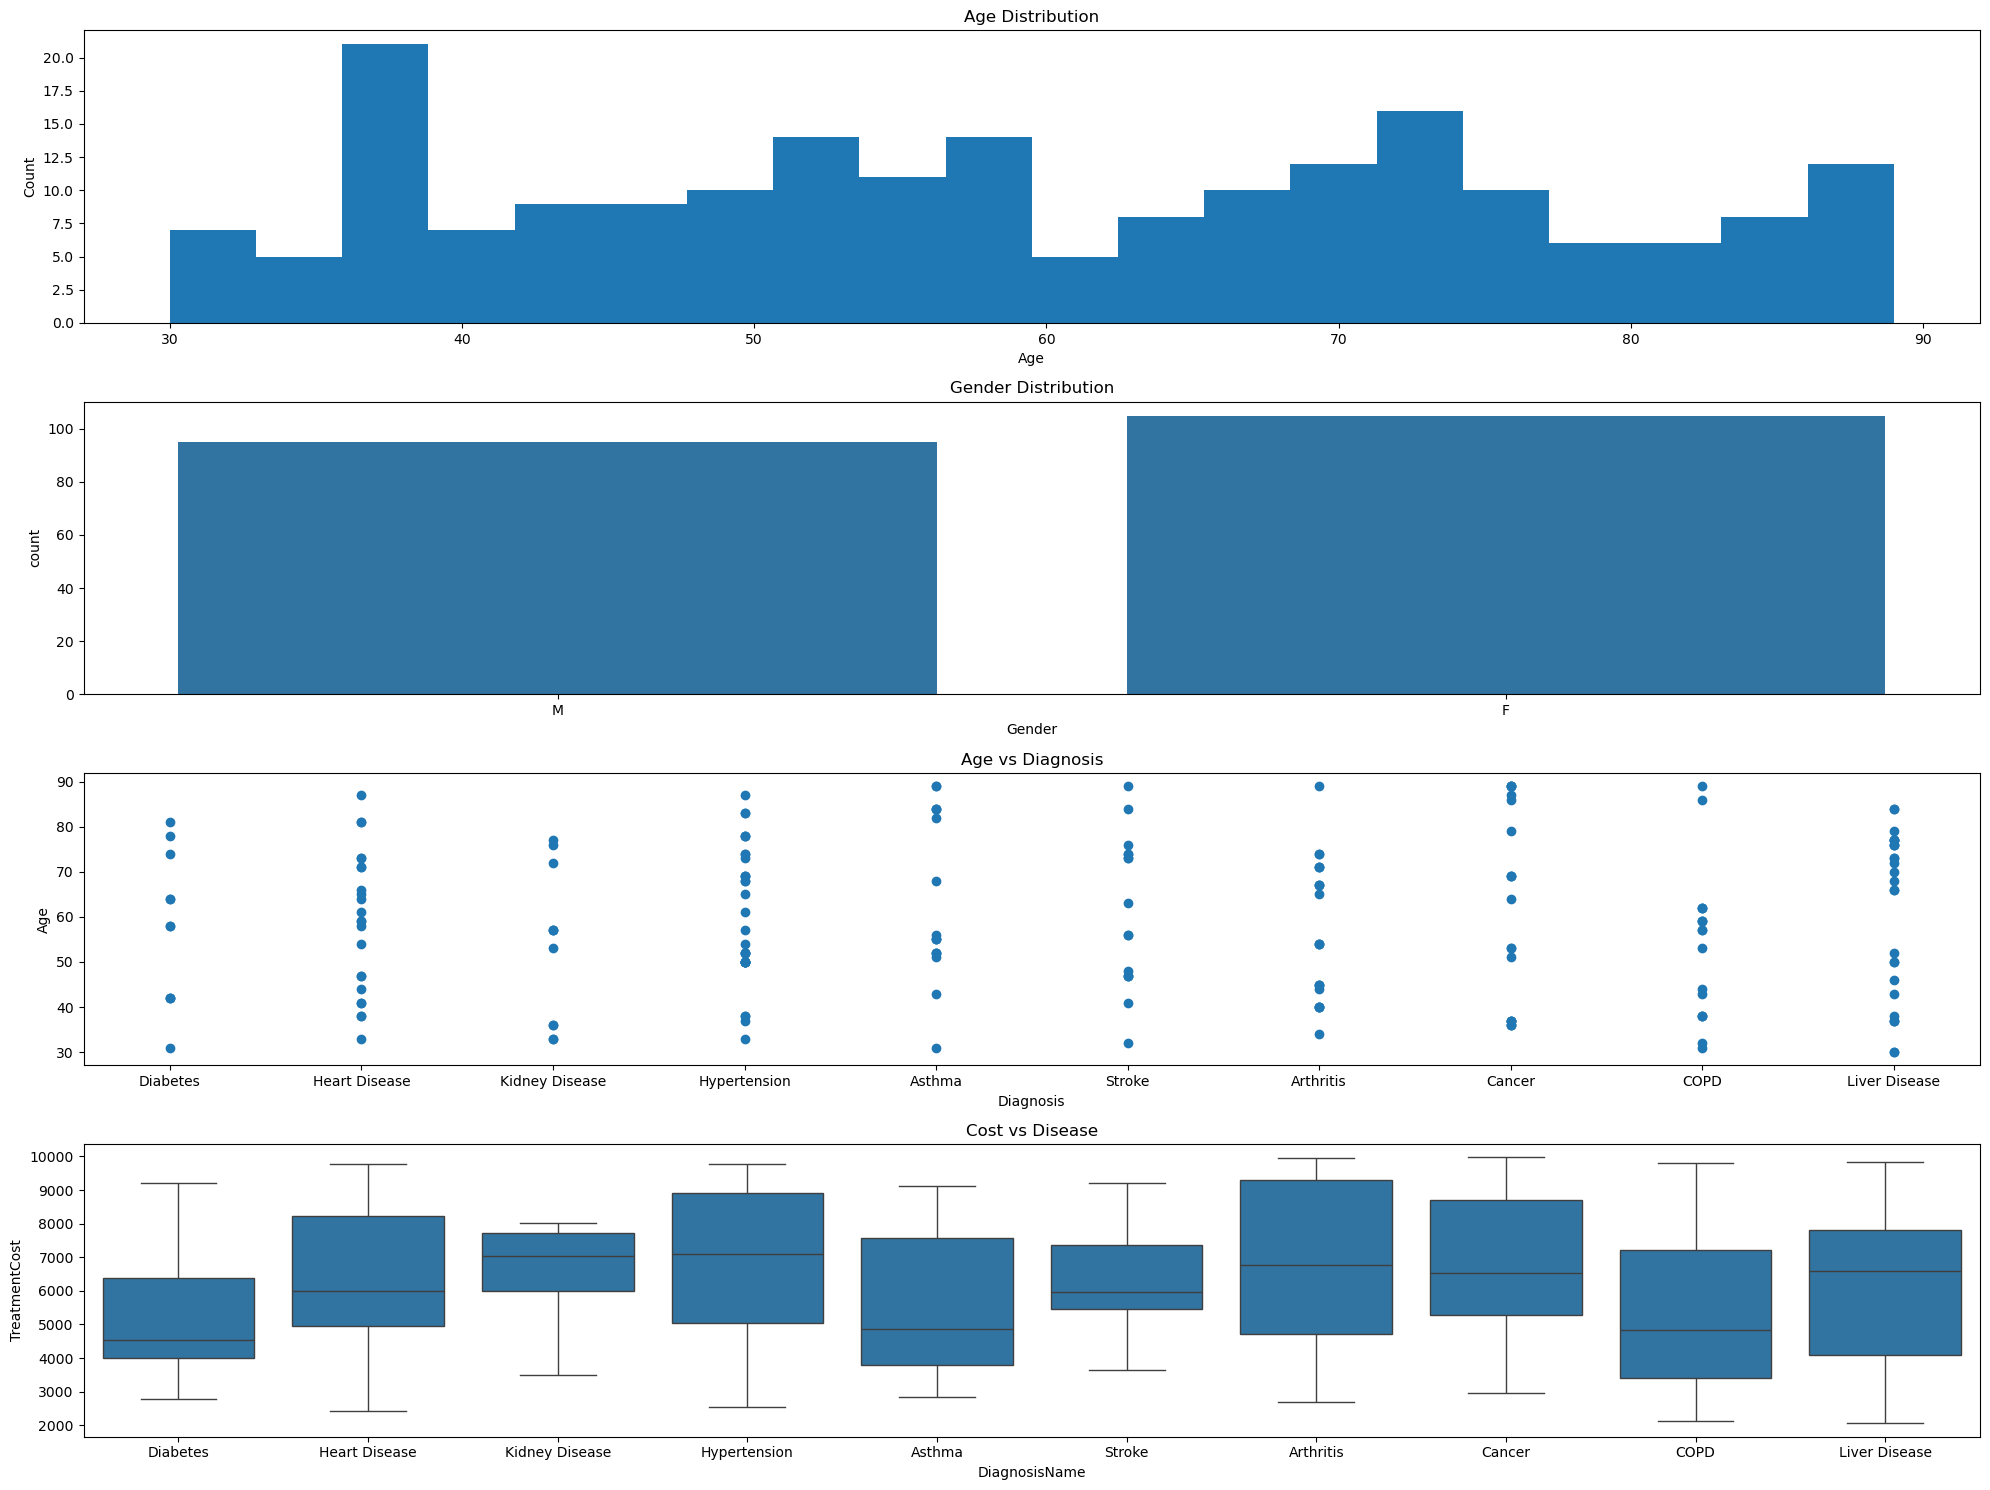

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(4, 1, figsize=(20,15))

# Univariate Plot 1 - Histogram
ax[0].hist(df['Age'], bins=20)
ax[0].set_title("Age Distribution")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Count")

# Univariate Plot 2 - Count Plot
sns.countplot(x='Gender', data=df, ax=ax[1])
ax[1].set_title("Gender Distribution")

# Bivariate Plot 1 - Scatter Plot
ax[2].scatter(df['DiagnosisName'], df['Age'])
ax[2].set_title("Age vs Diagnosis")
ax[2].set_ylabel("Age")
ax[2].set_xlabel("Diagnosis")

# Bivariate Plot 2 - Box Plot
sns.boxplot(x='DiagnosisName', y='TreatmentCost', data=df, ax=ax[3])
ax[3].set_title("Cost vs Disease")

plt.tight_layout()
plt.show()